# 1. Data Analysis Module

In [10]:
import pandas as pd
import numpy as np

# Load the dataset into a dataframe
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Print success message and display first 5 rows
print("Dataset loaded successfully!")
df.head()

# Check the current data types of all columns
print("--- Data types before cleaning ---")
df.info()

# Replace blank spaces in 'TotalCharges' with standard missing values (NaN)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Convert the column from text (object) to numeric format
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Fill the missing values with 0 (since these are usually new customers with 0 tenure)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify that the issue is fixed
print("\n--- Cleaning Complete ---")
print(f"Total missing values in TotalCharges now: {df['TotalCharges'].isnull().sum()}")

# Summary Statistics
print("<--- Summary Statistics --->")
display(df.describe())

Dataset loaded successfully!
--- Data types before cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 no

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# 2. Feature Engineering & Customer Segmentation

In [11]:
# List of extra services provided by the company
services_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

# Feature 1: TotalServices
# Calculate the total number of extra services a customer has (counting 'Yes')
df['TotalServices'] = (df[services_columns] == 'Yes').sum(axis=1)

# Feature 2: TenureInYears
# Convert 'tenure' from months to years by dividing by 12
df['TenureInYears'] = round(df['tenure'] / 12, 1)

# Print success message and display the new columns to verify
print("Feature Engineering is completed")
df[['customerID', 'tenure', 'TenureInYears', 'TotalServices']].head()

#Customer Segmentation

# Dividing customers into 3 equal groups based on their Monthly Charges
df['Customer Segment'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])
print("Customer Segmentation is completed ")
print("\n--- Number of Customers in Each Segment ---")
print(df['Customer Segment'].value_counts())

# Display the data
df[['customerID', 'MonthlyCharges', 'Customer Segment']].head()

Feature Engineering is completed
Customer Segmentation is completed 

--- Number of Customers in Each Segment ---
Customer Segment
Low Value       2351
High Value      2347
Medium Value    2345
Name: count, dtype: int64


,customerID,MonthlyCharges,Customer Segment
0,7590-VHVEG,29.85,Low Value
1,5575-GNVDE,56.95,Medium Value
2,3668-QPYBK,53.85,Medium Value
3,7795-CFOCW,42.30,Low Value
4,9237-HQITU,70.70,Medium Value


# 3. Data Visualization

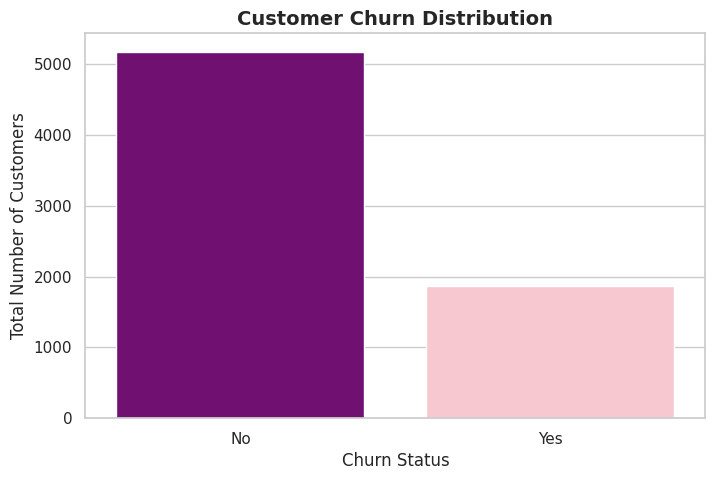

Churn Distribution Chart 


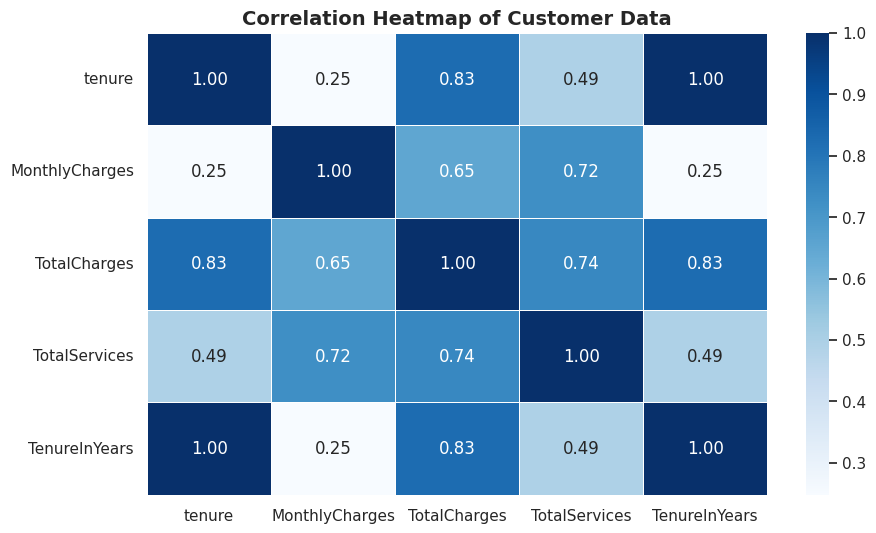

Correlation Heatmap


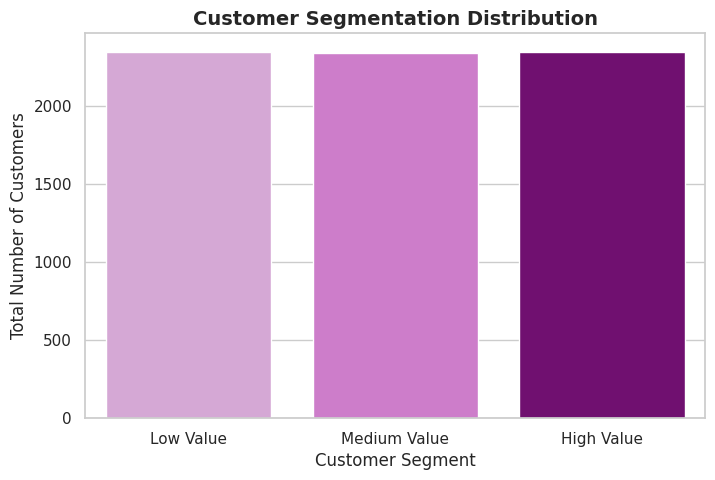

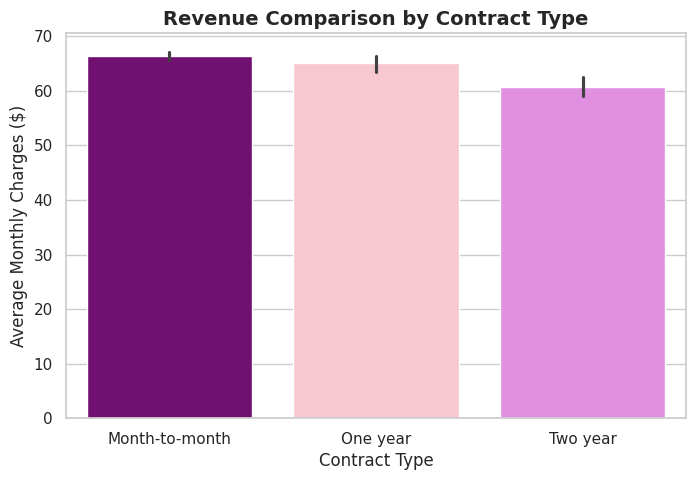

In [12]:
# Libraries used for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Visual identity setup
sns.set_theme(style="whitegrid")
custom_colors = ["purple", "pink"]
segment_colors = ["plum", "orchid", "purple"]
revenue_colors = ["purple", "pink", "violet"]

# --- This is the first chart --> Customer Churn Distribution ---
plt.figure(figsize=(8, 5))
churn_plot = sns.countplot(data=df, x='Churn', hue='Churn', palette=custom_colors, legend=False)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Total Number of Customers', fontsize=12)
plt.savefig('churn_distribution_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Churn Distribution Chart ")

# --- Correlation Heatmap ---
# Only numeric columns from  dataset
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'TenureInYears']
numeric_data = df[numeric_columns]
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 6))
# Plotting the heatmap --> annot=True shows the exact numbers inside the boxes
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Customer Data', fontsize=14, fontweight='bold')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation Heatmap")

# --- Customer Segmentation Chart ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Customer Segment', hue='Customer Segment', palette=segment_colors, legend=False)
plt.title('Customer Segmentation Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Number of Customers', fontsize=12)
plt.savefig('customer_segmentation_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Revenue Trends (Category-wise Comparison) ---
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Contract', palette=revenue_colors, legend=False)
plt.title('Revenue Comparison by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Average Monthly Charges ($)', fontsize=12)
plt.savefig('revenue_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Machine Learning Modeling

In [13]:
from sklearn.model_selection import train_test_split

# Convert the target variable 'Churn' from text to binary numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select others important text columns that affect churn
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

# Convert these text columns into 1s and 0s using --> One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Combined our previous numeric features with these encoded features
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices'] + [col for col in df_encoded.columns if col.startswith(tuple(categorical_cols))]

X = df_encoded[features]
y = df_encoded['Churn']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing and train-test split is completed")
print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train a Random Forest model --> using max_depth to prevent overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and accuracy
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Model Training is completed \n")
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

Data preprocessing and train-test split is completed
Training data size: 5634 samples
Testing data size: 1409 samples

Random Forest Model Training is completed 

Model Accuracy: 79.91%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



# 5. Model Evaluation (ROC-AUC) & Logistic Regression

Random Forest ROC-AUC Score: 0.8421



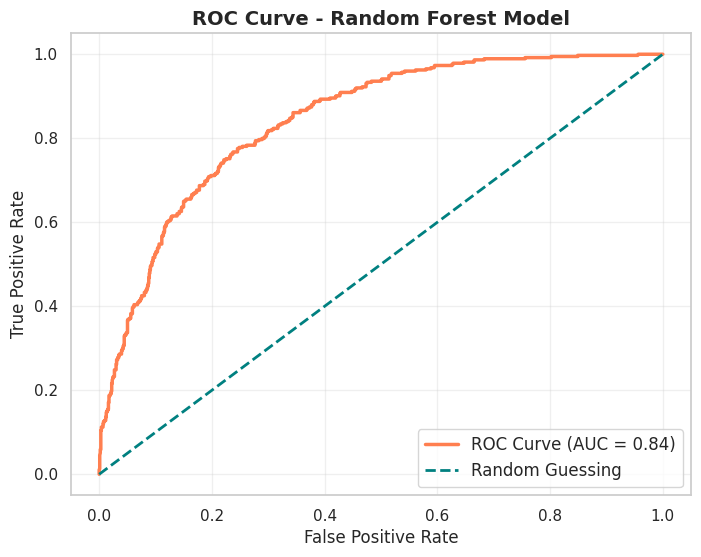


Logistic Regression Training is completed

Logistic Regression Accuracy: 79.56%
Logistic Regression ROC-AUC Score: 0.8353

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



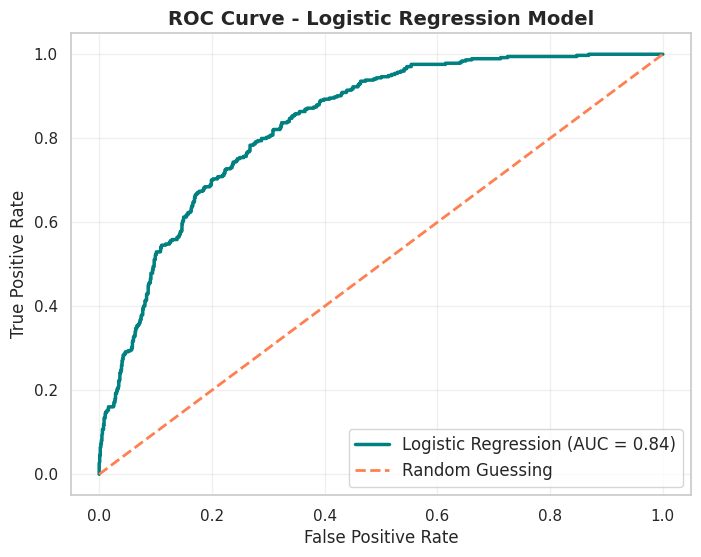

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities for the positive class --> Churn = 1
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC-AUC Score to measure model performance
roc_auc = roc_auc_score(y_test, y_prob)
print(f"Random Forest ROC-AUC Score: {roc_auc:.4f}\n")

# Compute the False Positive Rate (FPR) and True Positive Rate (TPR) for the curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Create ROC Curve plot
plt.figure(figsize=(8, 6))
# Plot the model's performance line using coral to match  visual identity
plt.plot(fpr, tpr, color='coral', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Plot the baseline
plt.plot([0, 1], [0, 1], color='teal', linestyle='--', linewidth=2, label='Random Guessing')
# Styling, labels, and title
plt.title('ROC Curve - Random Forest Model', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Applying standard scaler to make features scaled in a standard range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("\nLogistic Regression Training is completed\n")
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Logistic Regression ROC-AUC Score: {lr_roc_auc:.4f}\n")
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

# Compute the False Positive Rate (FPR) and True Positive Rate (TPR) for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='teal', linewidth=2.5, label=f'Logistic Regression (AUC = {lr_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='coral', linestyle='--', linewidth=2, label='Random Guessing')
plt.title('ROC Curve - Logistic Regression Model', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve_lr.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Basic Prediction System


Risk Categories assigned !


,customerID,Churn_Probability,Risk Category
0,7590-VHVEG,0.658706,Medium Risk
1,5575-GNVDE,0.064044,Low Risk
2,3668-QPYBK,0.547922,Medium Risk
3,7795-CFOCW,0.098138,Low Risk
4,9237-HQITU,0.616013,Medium Risk


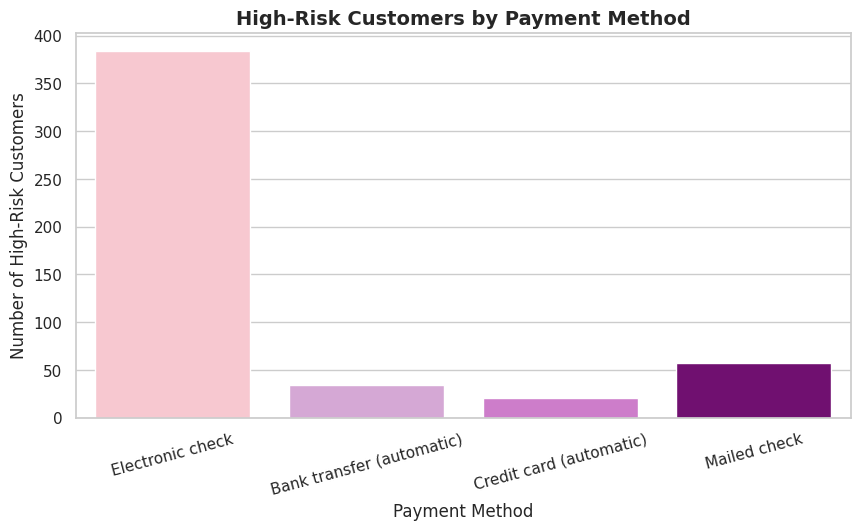

In [15]:
# Risk Categories
df['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]

# Customers based on their churn probability
def assign_risk(probability):
    if probability < 0.30:
        return 'Low Risk'
    elif probability < 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Function to create a new column for Risk Category
df['Risk Category'] = df['Churn_Probability'].apply(assign_risk)

print("\nRisk Categories assigned !")
# Display the customer ID, Probability, and Risk Category
display(df[['customerID', 'Churn_Probability', 'Risk Category']].head())

# --- High-Risk Customers by Payment Method ---
high_risk_data = df[df['Risk Category'] == 'High Risk']

plt.figure(figsize=(10, 5))
sns.countplot(data=high_risk_data, x='PaymentMethod', hue='PaymentMethod', palette=["pink", "plum", "orchid", "purple"], legend=False)
plt.title('High-Risk Customers by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of High-Risk Customers', fontsize=12)
plt.xticks(rotation=15)
plt.savefig('high_risk_payment_methods.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Bonus Challenge: SHAP Explainability (Feature Importance)

**Objective:** Machine Learning models are often considered "black boxes." To make our Optimized Random Forest model interpretable for business stakeholders, we are using **SHAP (SHapley Additive exPlanations)**.

This technique calculates the exact contribution of each feature to the model's predictions. By generating a SHAP Summary Plot, we can visually identify which specific customer behaviors (e.g., Contract type, Tenure, Total Charges) are the biggest drivers of customer churn.


In [16]:
# Install SHAP library
!pip install shap

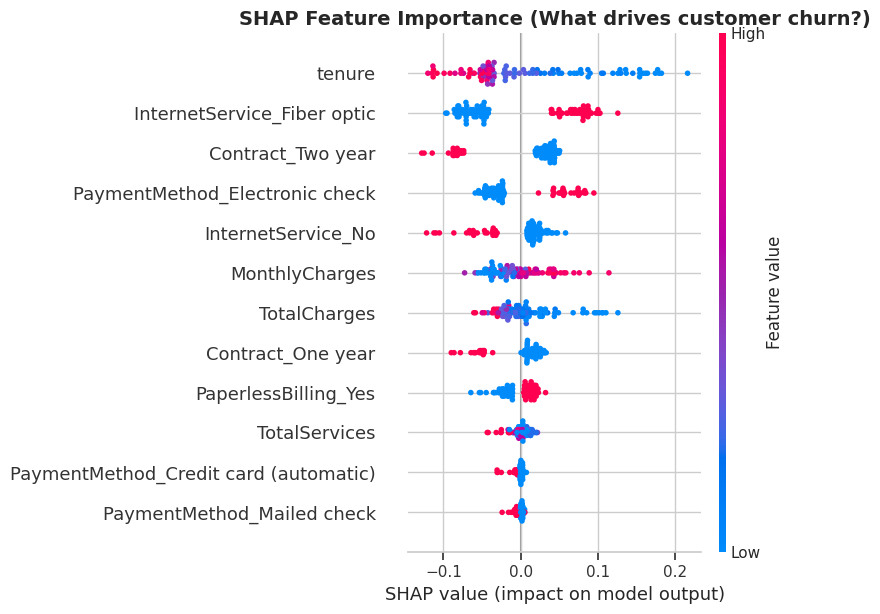

In [9]:
import shap
import matplotlib.pyplot as plt

# Initialize the SHAP Explainer with our trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test[:100])

# Extracting Class 1 - Churn values
if isinstance(shap_values, list):
    churn_shap_values = shap_values[1] # For older SHAP versions
else:
    if len(shap_values.shape) == 3:
        churn_shap_values = shap_values[:, :, 1]
    else:
        churn_shap_values = shap_values

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title('SHAP Feature Importance (What drives customer churn?)', fontsize=14, fontweight='bold')

# Plotting the summary
shap.summary_plot(churn_shap_values, X_test[:100], show=False)

# Save the plot
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()
